<a href="https://colab.research.google.com/github/RichardEager0803/Machine-Learning/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment #2 Experiments & Tasks

#### Data Preparation, Pipelines, and Exploratory Data Analysis

Goals:


*   Source a real-world dataset from Kaggle
*   Inspect its structure
*   Handle missing data
*   Construct automated preprocessing pipelines using Scikit-Learn
*   Perform comprehensive exploratory data analysis and correlation visualization without training any machine learning models




1. Loads the dataset into a Pandas DataFrame (called df).
2. Uses the inspection methods (head(), info(), and describe()) to analyze features.

In [1]:
import pandas as pd

df = pd.read_csv('cybersecurity_intrusion_data.csv')

print("\nHead Method: ")
print(df.head())

print("\nInfo Method: ")
print(df.info())

print("\nDescribe Method: ")
print(df.describe())


Head Method: 
  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected  
0         Edge                    0                1  
1      Firefox       

3. Drops any non-informative identifiers. (In this case sesssion_id)

In [2]:
df_clean = df.drop(columns=["session_id"], errors="ignore")

4. Checks Missing Values Before Pipeline Processing, and defines column groups.

In [3]:
print("\nMissing values before pipeline execution:")
print(df_clean.isnull().sum())

numeric_cols = [
    "network_packet_size",
    "login_attempts",
    "session_duration",
    "ip_reputation_score",
    "failed_logins",
    "unusual_time_access",
]

categoric_cols = [
    "protocol_type",
    "encryption_used",
    "browser_type"
]

target_col = "attack_detected"


Missing values before pipeline execution:
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64


5. Uses Scikit-Learn's SimpleImputer to handle the missing entries. Then with the isolated numerical and categoric features, we can now build the Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (e.g., StandardScaler) to numerical columns and encoding (e.g., OneHotEncoder) to categorical columns.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Isolates Features (X) and Target (y)
X = df_clean[numeric_cols + categoric_cols]
y = df_clean[target_col]

# Builds Scikit-Learn Pipelines (Imputation + Scaling / Encoding)
numeric_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categoric_cols),
    ]
)

# Splits the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fits the preprocessor ONLY on the training features, then transforms both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Reconstructs the processed DataFrames (example for training data)
encoded_cat_cols = preprocessor.named_transformers_["cat"][
    "onehot"
].get_feature_names_out(categoric_cols)
all_feature_names = numeric_cols + list(encoded_cat_cols)

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names)


print("\nMissing values after pipeline execution (Train set):")
print(X_train_processed_df.isnull().sum())

print("\n\nProcessed Training Feature Matrix Shape:", X_train_processed_df.shape)
print(X_train_processed_df.head(n=10))



Missing values after pipeline execution (Train set):
network_packet_size     0
login_attempts          0
session_duration        0
ip_reputation_score     0
failed_logins           0
unusual_time_access     0
protocol_type_ICMP      0
protocol_type_TCP       0
protocol_type_UDP       0
encryption_used_AES     0
encryption_used_DES     0
encryption_used_None    0
browser_type_Chrome     0
browser_type_Edge       0
browser_type_Firefox    0
browser_type_Safari     0
browser_type_Unknown    0
dtype: int64


Processed Training Feature Matrix Shape: (7629, 17)
   network_packet_size  login_attempts  session_duration  ip_reputation_score  \
0             0.474825       -1.041407         -0.501689            -1.269165   
1             0.027944        1.010344         -0.990232            -1.524004   
2             1.915890       -0.528469          0.859324            -0.874540   
3            -1.287594        0.497406         -0.218028             0.579108   
4            -0.198007       -0.

6. Computes the Pearson Correlation matrix for the numerical features, generates a Seaborn heatmap with annotations, and creates two distribution plots, and one scatter plot to examine the feature relationships and the target variable (attack_detected).

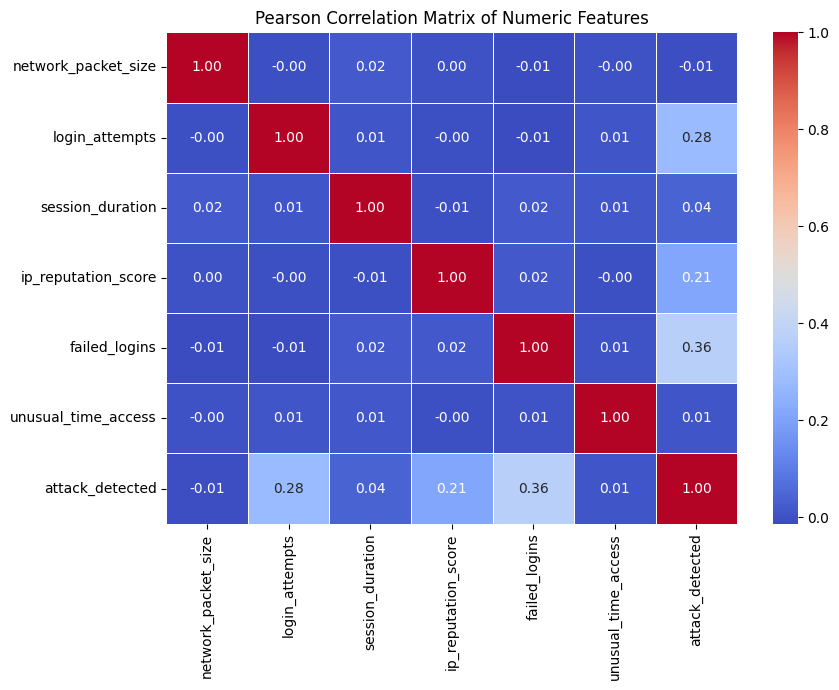

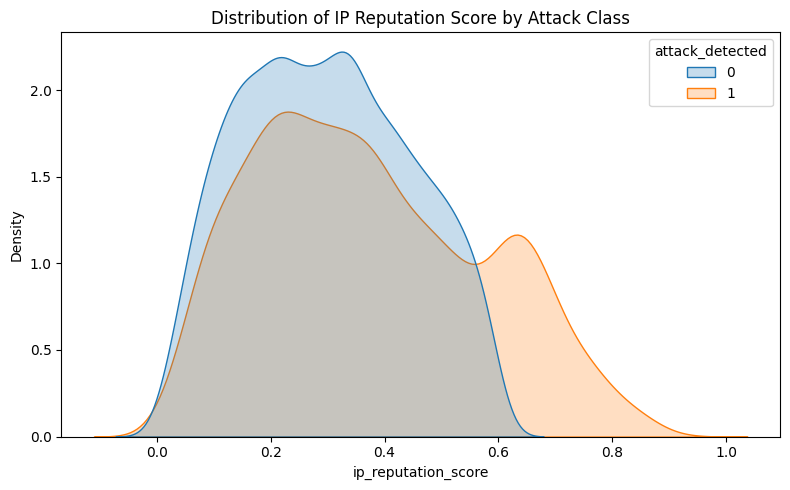

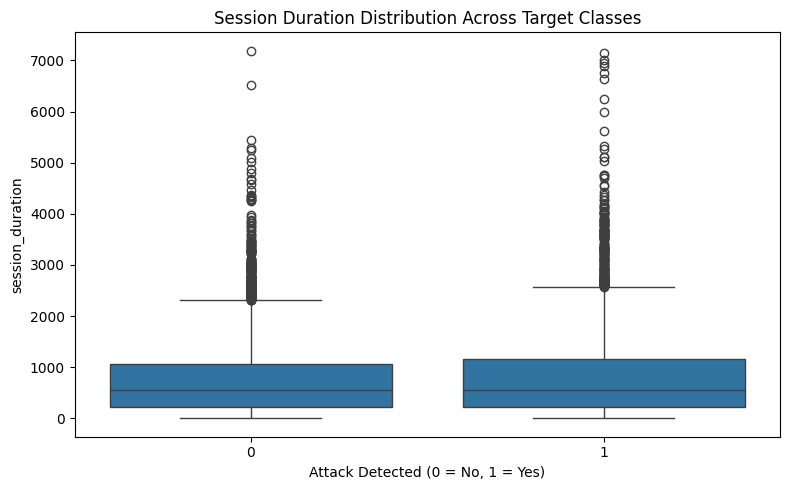

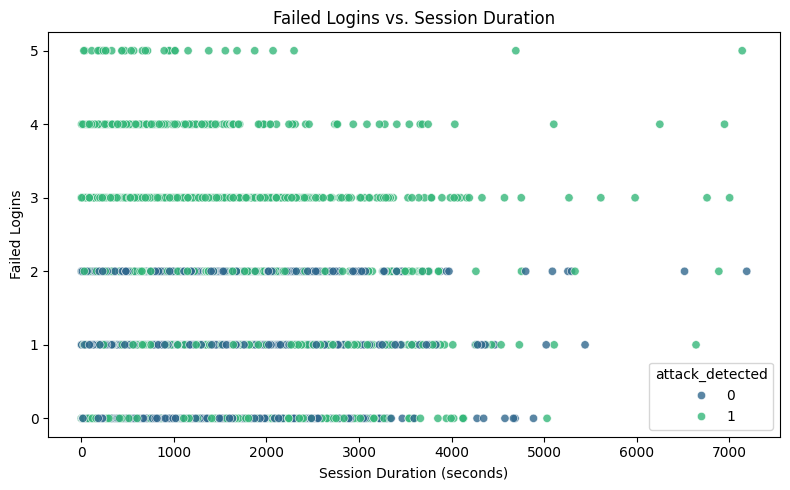

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Pearson Correlation Computation check (using pandas .corr())
plt.figure(figsize=(9, 7))
corr_matrix = df_clean[numeric_cols + [target_col]].corr(method="pearson")
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()
print("\n\n")

# Distribution Plot 1: KDE of IP Reputation Score
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df_clean,
    x="ip_reputation_score",
    hue=target_col,
    fill=True,
    common_norm=False,
)
plt.title("Distribution of IP Reputation Score by Attack Class")
plt.tight_layout()
plt.show()
print("\n\n")

# Distribution Plot 2: Boxplot of Session Duration
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x=target_col, y="session_duration")
plt.title("Session Duration Distribution Across Target Classes")
plt.xlabel("Attack Detected (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()
print("\n\n")

# Scatter Plot: Failed Logins vs. Session Duration
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="session_duration",
    y="failed_logins",
    hue=target_col,
    palette="viridis",
    alpha=0.8,
)
plt.title("Failed Logins vs. Session Duration")
plt.xlabel("Session Duration (seconds)")
plt.ylabel("Failed Logins")
plt.tight_layout()
plt.show()
print("\n\n")
